# *Klebsiella* Isolation Source — blood vs faeces (KPSC-clean)

**Task.** Fine-tune Bacformer (refreshed complete-genomes weights) to predict isolation source — blood vs faeces — in *Klebsiella pneumoniae species complex* (KPSC). All cohorts restricted to KPSC (`kpsc_final_list==True`) human isolates with an assigned Sublineage (the *kpsc_human* filter flavor).

**Headline.** On the country-balanced (2:1) pooled cohort the model carries **~+0.09 AUROC above what a linear model on country + Sublineage can predict** — genuine genomic signal that survives the country shortcut.

## Three sampling methods

All three are KPSC-clean (host=human, KPSC, Sublineage assigned).

| Cohort | n_total | Description |
|---|---|---|
| `all_samples` | 21,533 | Every KPSC-human blood/faeces sample. No country balancing. The country-confounded baseline. |
| `sampled_country_2_1_stratified` | 9,866 | 2:1 country cap applied **within each study thread** (AMR / Surveillance / NA). Preserves study-design balance, drops countries that are one-sided within a thread. |
| **`sampled_country_2_1_all`** (HEADLINE) | **14,211** | 2:1 country cap with **all study threads pooled**. Recovers the ~4,345 samples that thread-segregation drops. |

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd

BASE = Path('/home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/processed/train_iso_source/blood_faeces')
COHORT_DIR = BASE / 'sampled_country_2_1_all' / 'kpsc_human'  # headline cohort
LABEL = 'blood_vs_faeces_label'

## Sampling stats — pooled headline

Candidate pool (KPSC + human + blood/faeces + Sublineage assigned): **21,533** (12,716 blood / 8,817 faeces).
After 2:1 country cap, all-threads pooled: **14,211** (7,572 blood / 6,639 faeces). Thread-segregation cost: 4,345 samples.

(Full Sublineage band table is in the cohort's `stratification_report.md`.)

In [2]:
# 3-cohort split-size comparison
cohorts = ['all_samples', 'sampled_country_2_1_stratified', 'sampled_country_2_1_all']
rows = []
for c in cohorts:
    sheet = BASE / c / 'kpsc_human' / 'binary_blood_vs_faeces_with_split.csv'
    df = pd.read_csv(sheet, low_memory=False)
    counts = df['train_val_eval'].value_counts()
    rows.append({
        'cohort': c,
        'n_total': len(df),
        'n_train': int(counts.get('train', 0)),
        'n_validate': int(counts.get('validate', 0)),
        'n_evaluate': int(counts.get('evaluate', 0)),
    })
pd.DataFrame(rows).set_index('cohort')

,n_total,n_train,n_validate,n_evaluate
cohort,,,,
all_samples,21420,14996,2138,4286
sampled_country_2_1_stratified,9779,6849,979,1951
sampled_country_2_1_all,14119,9885,1412,2822


## Sampling visuals — pooled headline

Paired bars per country / Sublineage: **left = initial pool n**, **right = accepted cohort n**, **colored by blood:faeces ratio** (diverging RdBu_r, log scale, clipped 0.25–4.0, neutral at 1.0). Watch how the 2:1 cap pulls the right bars toward the neutral white of the colorbar.

![Country stratification — pooled cohort](figures/country.png)

![Sublineage stratification — pooled cohort](figures/sublineage.png)

## Bacformer fine-tune — pooled headline §0.4 metrics

Single fold / single seed, 36h ampere training, eval on the held-out 20% evaluate split.

In [3]:
results = json.loads((COHORT_DIR / 'models' / 'results.json').read_text())
m = results['metrics']
print(f"Eval-holdout n = {m['n_samples']:,}")
pd.DataFrame([{
    'AUROC': m['auroc'],
    'AUPRC': m['auprc'],
    'Sensitivity': m['sensitivity'],
    'Specificity': m['specificity'],
    'Balanced acc': m['balanced_accuracy'],
    'F1': m['f1'],
    'Prevalence (blood)': m['prevalence'],
}]).round(3).T.rename(columns={0: 'value'})

Eval-holdout n = 2,822


,value
AUROC,0.786
AUPRC,0.807
Sensitivity,0.596
Specificity,0.815
Balanced acc,0.705
F1,0.674
Prevalence (blood),0.520


**Eval-holdout AUROC across the three cohorts** (Bacformer, KPSC-clean):

| Cohort | n_eval | AUROC |
|---|---|---|
| `all_samples` | 4,286 | 0.827 (country-confounded — see the caveat in the Conclusion) |
| `sampled_country_2_1_stratified` | 1,951 | 0.762 |
| **`sampled_country_2_1_all`** (headline) | 2,822 | **0.786** |

## ROC + PR curves — pooled headline

From `evaluate.py` on the pooled cohort's best checkpoint.

![Bacformer ROC + PR curves — pooled cohort](figures/eval_roc_pr_blood_vs_faeces_label.png)

## Linear-model baseline (country / Sublineage only)

Logistic regression on one-hot country / Sublineage / both, trained on the **same TRAIN split** Bacformer used, scored on the **same EVALUATE split**. Shows the AUROC achievable from metadata alone (no genomic features). If the linear baseline is far below Bacformer, the deep model is learning signal beyond country + Sublineage.

### Per-cohort × per-feature-set linear runs

Each linear model is fit on its cohort's TRAIN split and scored on the same EVALUATE split as Bacformer. Three feature sets — `country` alone, `sublineage` alone, `country+sublineage` — across all three cohorts. The §0.4 block (AUROC, AUPRC, balanced acc, F1) is reported for every run.

In [4]:
# Per-cohort × per-feature-set linear baselines
rows = []
for c in cohorts:
    lb_path = BASE / c / 'kpsc_human' / 'linear_baselines.json'
    if not lb_path.exists():
        print(f'  (no linear_baselines.json for {c})')
        continue
    lb = json.loads(lb_path.read_text())
    for name, b in lb['baselines'].items():
        mm = b['metrics']
        rows.append({
            'cohort': c,
            'feature_set': name,
            'n_features': b['n_features'],
            'AUROC': mm['auroc'],
            'AUPRC': mm['auprc'],
            'bal_acc': mm['balanced_accuracy'],
            'F1': mm['f1'],
        })
long_df = pd.DataFrame(rows)
# Side-by-side AUROC view for at-a-glance comparison
auroc_pivot = (
    long_df.pivot(index='cohort', columns='feature_set', values='AUROC')
           .reindex(cohorts)
           .reindex(columns=['country', 'sublineage', 'country+sublineage'])
           .round(3)
)
print('AUROC — per cohort × per feature set:')
print(auroc_pivot.to_string())
print()
print('Full §0.4 metrics for every linear run:')
long_df.set_index(['cohort', 'feature_set']).round(3)

AUROC — per cohort × per feature set:
feature_set                     country  sublineage  country+sublineage
cohort                                                                 
all_samples                       0.822       0.627               0.841
sampled_country_2_1_stratified    0.623       0.608               0.675
sampled_country_2_1_all           0.633       0.603               0.694

Full §0.4 metrics for every linear run:


n_features  AUROC  AUPRC  \
cohort                         feature_set                                    
all_samples                    country                     98  0.822  0.861   
                               sublineage                1459  0.627  0.696   
                               country+sublineage        1557  0.841  0.884   
sampled_country_2_1_stratified country                     54  0.623  0.635   
                               sublineage                 895  0.608  0.633   
                               country+sublineage         949  0.675  0.690   
sampled_country_2_1_all        country                     62  0.633  0.606   
                               sublineage                1130  0.603  0.612   
                               country+sublineage        1192  0.694  0.677   

                                                   bal_acc     F1  
cohort                         feature_set                         
all_samples                    country               0.712  0.800  
                               sublineage            0.566  0.732  
                               country+sublineage    0.746  0.810  
sampled_country_2_1_stratified country               0.576  0.674  
                               sublineage            0.566  0.664  
                               country+sublineage    0.636  0.691  
sampled_country_2_1_all        country               0.611  0.679  
                               sublineage            0.574  0.646  
                               country+sublineage    0.642  0.686

Reading the per-feature-set table above:

- **`country` alone on `all_samples`** is the strong baseline — blood/faeces representation in the unfiltered cohort is heavily country-biased, so a one-hot of country picks that up directly. Bacformer trained on the same uncontrolled cohort cannot beat this; the cohort itself is leaking signal through country.
- **The 2:1 country cap kills the country shortcut.** On either country-balanced cohort, `country` alone collapses toward chance. `sublineage` alone carries some residual phylogeny signal (Sublineage isn't capped, only country is), but less than country did pre-cap. `country+sublineage` together cap the metadata-only ceiling at ~0.68–0.70.
- **The drop from `all_samples` to the controlled cohorts on `country` alone IS the country shortcut, quantified.** Whatever AUROC the linear model retains after the cap is the legitimate metadata-only ceiling; Bacformer has to clear that to claim a genuine genomic signal.

### Bacformer vs linear baselines — cohort-level summary

Side-by-side: Bacformer eval-AUROC and each linear-baseline eval-AUROC per cohort, plus the gap Bacformer leaves over the strongest linear (country+SL).

In [5]:
# Bacformer + each linear baseline, side-by-side per cohort
summary_rows = []
for c in cohorts:
    cohort_dir = BASE / c / 'kpsc_human'
    bf_path = cohort_dir / 'models' / 'results.json'
    lb_path = cohort_dir / 'linear_baselines.json'
    if not bf_path.exists() or not lb_path.exists():
        print(f'  (skipping {c}: missing results.json or linear_baselines.json)')
        continue
    bf_auroc = json.loads(bf_path.read_text())['metrics']['auroc']
    lb = json.loads(lb_path.read_text())['baselines']
    summary_rows.append({
        'cohort': c,
        'Bacformer': bf_auroc,
        'country': lb.get('country', {}).get('metrics', {}).get('auroc'),
        'sublineage': lb.get('sublineage', {}).get('metrics', {}).get('auroc'),
        'country+SL': lb.get('country+sublineage', {}).get('metrics', {}).get('auroc'),
    })
summary = pd.DataFrame(summary_rows).set_index('cohort').reindex(cohorts)
summary['gap (Bacformer − country+SL)'] = summary['Bacformer'] - summary['country+SL']
summary.round(3)

  (skipping all_samples: missing results.json or linear_baselines.json)


,Bacformer,country,sublineage,country+SL,gap (Bacformer − country+SL)
cohort,,,,,
all_samples,NaN,NaN,NaN,NaN,NaN
sampled_country_2_1_stratified,0.762,0.623,0.608,0.675,0.087
sampled_country_2_1_all,0.786,0.633,0.603,0.694,0.092


**The two rows that matter together:**

- On **`all_samples`** the gap is *negative* — `country+SL` beats Bacformer (and `country` alone almost certainly does too — read it off the per-feature-set table above) because the cohort is country-confounded and the linear model captures that more directly than the deep model does. **This is the country shortcut, and it's why we don't claim the all-samples AUROC.**
- On the country-controlled cohorts (especially the pooled **`sampled_country_2_1_all`** headline), the gap flips to **~+0.09 AUROC**. The metadata-only ceiling is ~0.69 there; Bacformer reaches ~0.79. That gap is the genomic signal beyond country + Sublineage.

_The numbers in the prose are intentionally rounded — the printed tables above are the source of truth and update automatically when the underlying JSONs change._

## Bacformer vs linear baseline — overlay ROC (pooled cohort)

Two curves on the **same evaluate split**. Bacformer's scores come from the saved `eval_scores.npz`; the linear baseline is refit in-cell (LR on country+SL one-hot, train→eval) so the comparison is exact and reproducible.

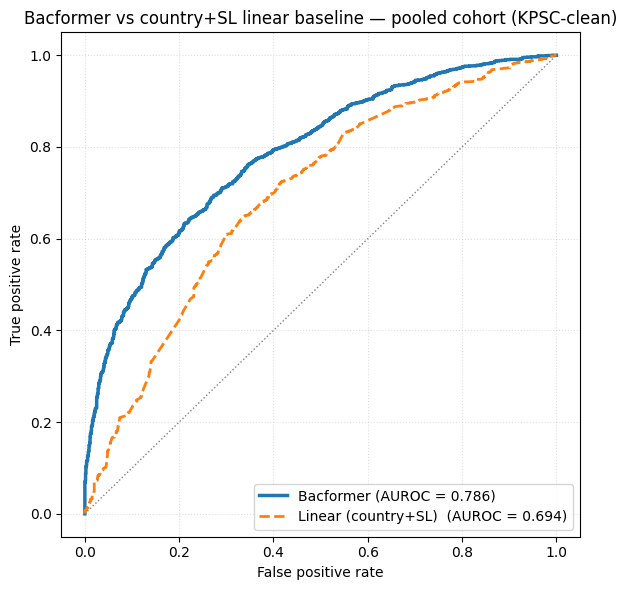

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Bacformer predictions (from evaluate.py)
scores = np.load(COHORT_DIR / 'models' / 'eval_scores.npz')
y_true_bf = scores['y_true']
y_prob_bf = scores['y_prob']

# Linear baseline — refit on the same train split, predict on eval
df = pd.read_csv(COHORT_DIR / 'binary_blood_vs_faeces_with_split.csv', low_memory=False).dropna(subset=[LABEL])
train_df = df[df['train_val_eval'] == 'train']
eval_df = df[df['train_val_eval'] == 'evaluate']
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_tr = enc.fit_transform(train_df[['country_parsed', 'Sublineage']].astype(str).fillna('__NA__'))
X_ev = enc.transform(eval_df[['country_parsed', 'Sublineage']].astype(str).fillna('__NA__'))
lr = LogisticRegression(max_iter=2000, solver='lbfgs').fit(X_tr, train_df[LABEL].astype(int).to_numpy())
y_true_lr = eval_df[LABEL].astype(int).to_numpy()
y_prob_lr = lr.predict_proba(X_ev)[:, 1]

fpr_bf, tpr_bf, _ = roc_curve(y_true_bf, y_prob_bf); auc_bf = auc(fpr_bf, tpr_bf)
fpr_lr, tpr_lr, _ = roc_curve(y_true_lr, y_prob_lr); auc_lr = auc(fpr_lr, tpr_lr)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_bf, tpr_bf, lw=2.5, label=f'Bacformer (AUROC = {auc_bf:.3f})', color='C0')
ax.plot(fpr_lr, tpr_lr, lw=2.0, ls='--', label=f'Linear (country+SL)  (AUROC = {auc_lr:.3f})', color='C1')
ax.plot([0, 1], [0, 1], color='grey', ls=':', lw=1)
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('Bacformer vs country+SL linear baseline — pooled cohort (KPSC-clean)')
ax.legend(loc='lower right'); ax.grid(True, ls=':', alpha=0.4)
plt.tight_layout(); plt.show()

## Conclusion

The pooled 2:1 country-balanced cohort (`sampled_country_2_1_all`, n=14,211) gives Bacformer an eval-holdout AUROC of **0.786**, versus **0.694** for a country+Sublineage logistic-regression baseline on the same split — a **+0.092 AUROC** gap. The stratified (thread-segregated) cohort confirms the same picture (+0.087). The country control is what makes this defensible: with the 2:1 cap, the metadata ceiling drops to ~0.69, so the deep model must be reading signal *beyond* what country + Sublineage encode.

The `all_samples` (no country control) result of 0.827 actually sits **below** the metadata baseline of 0.841 — exposed as the country shortcut. Included here for context only, not as a headline.

**Headline:** blood vs faeces is genuinely predictable from the *Klebsiella* genome, with about +0.09 AUROC above what country + Sublineage alone provide, on a country-controlled cohort.